In [15]:
from pathlib import Path
import sys
import os

# Cari root project: naik folder sampai ketemu main.py
project_root = Path.cwd()
while not (project_root / "main.py").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("Tidak menemukan main.py (root project tidak ketemu).")
    project_root = project_root.parent

# Tambahkan ke sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", project_root)

CWD: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS
PROJECT_ROOT: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS


In [18]:
import importlib
import sys

import src.references as ref
ref = importlib.reload(ref)

import main
main = importlib.reload(main)

print("Import berhasil")
print("references file:", ref.__file__)
print("get_default_config ada:", hasattr(ref, "get_default_config"))
print("main file:", main.__file__)

Import berhasil
references file: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS\src\references.py
get_default_config ada: True
main file: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS\main.py


Menjalankan analisa utama dari src.references... mode=synthetic
RMS sinyal    : 1.2202
RMS teoritis  : 1.2021  (tanpa noise)

Cek konsistensi magnitude:
max |amp - mag_X| = 1.11e-16  (harus mendekati 0)

Frekuensi dominan: 50.0 Hz  (amplitudo = 1.5021)


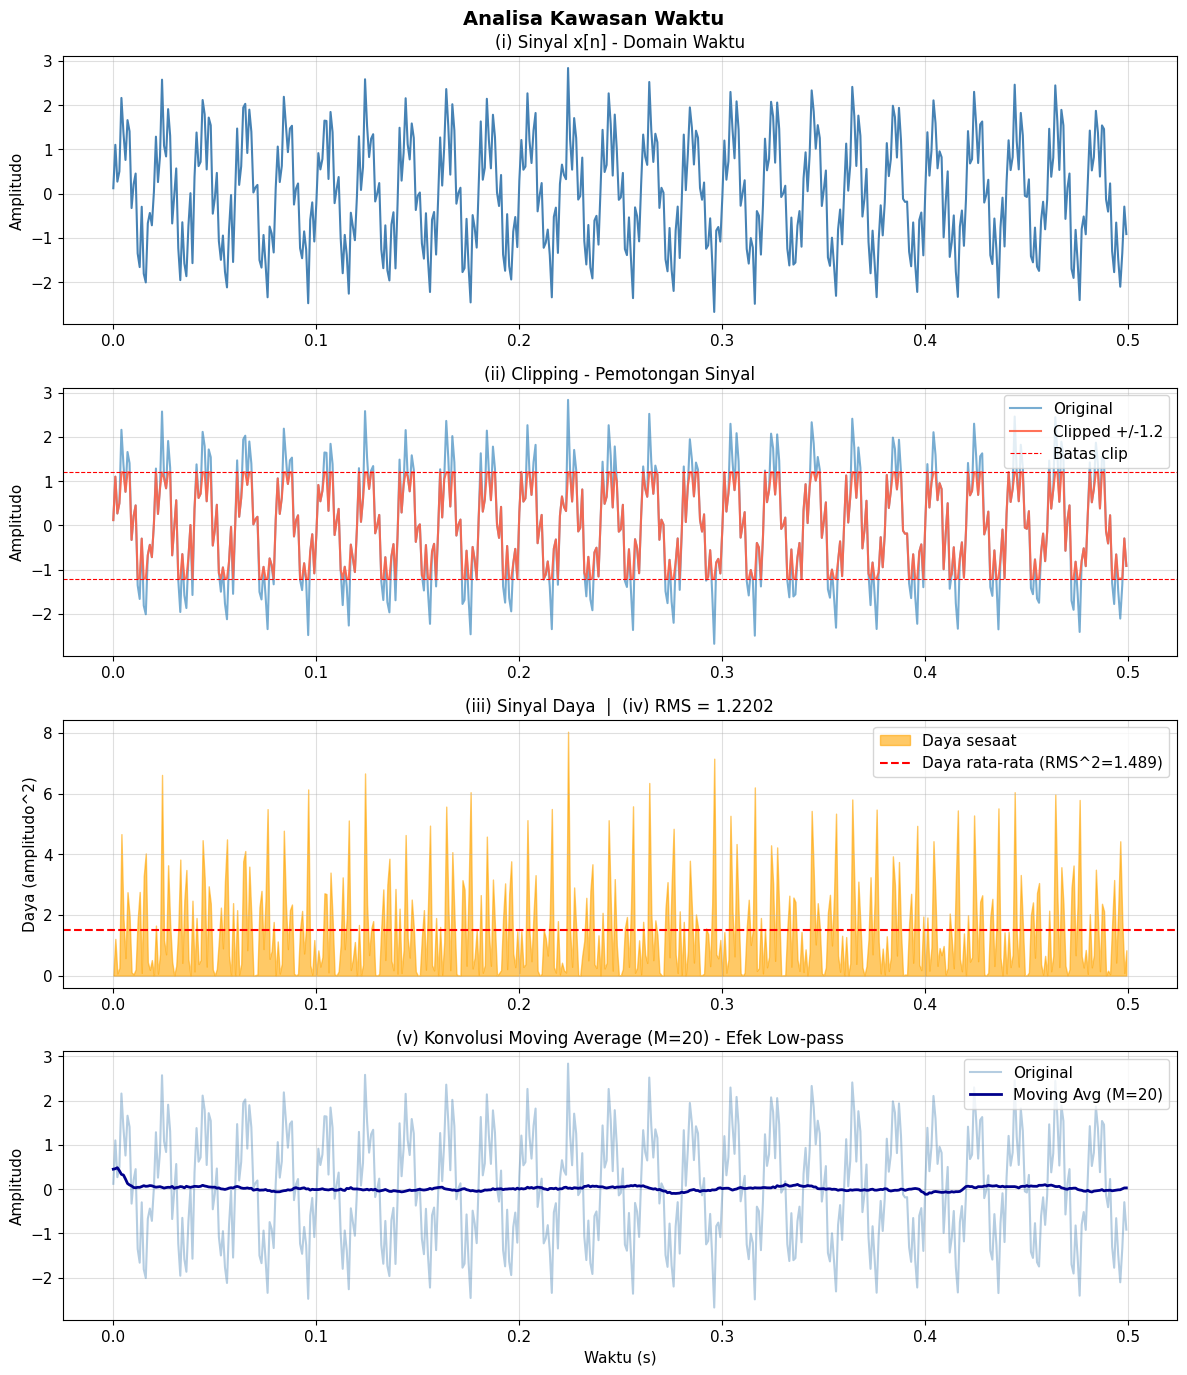

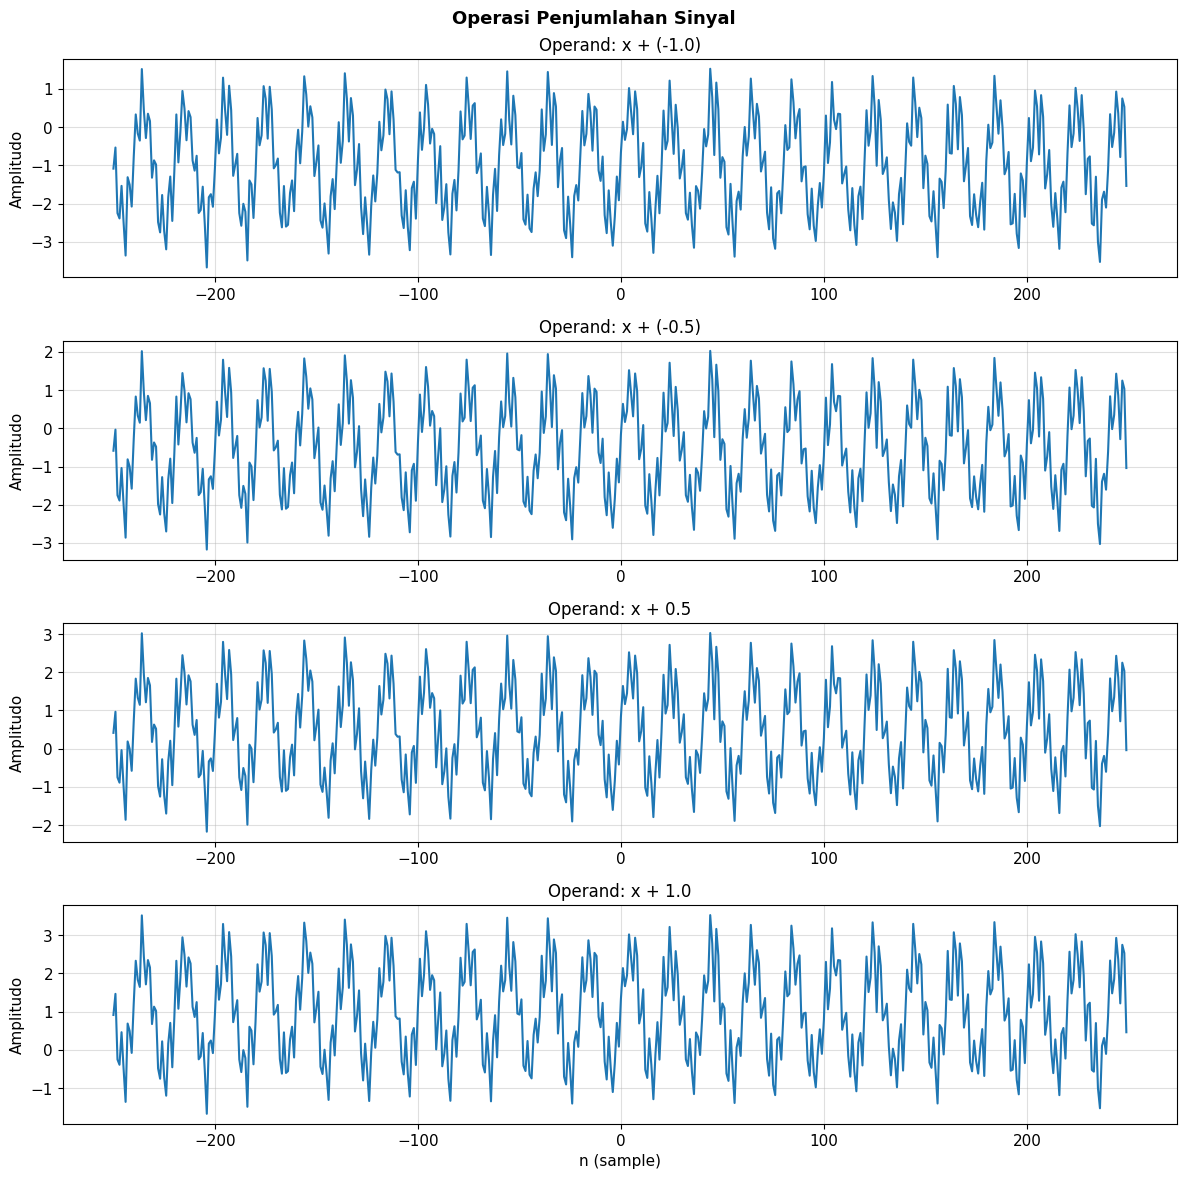

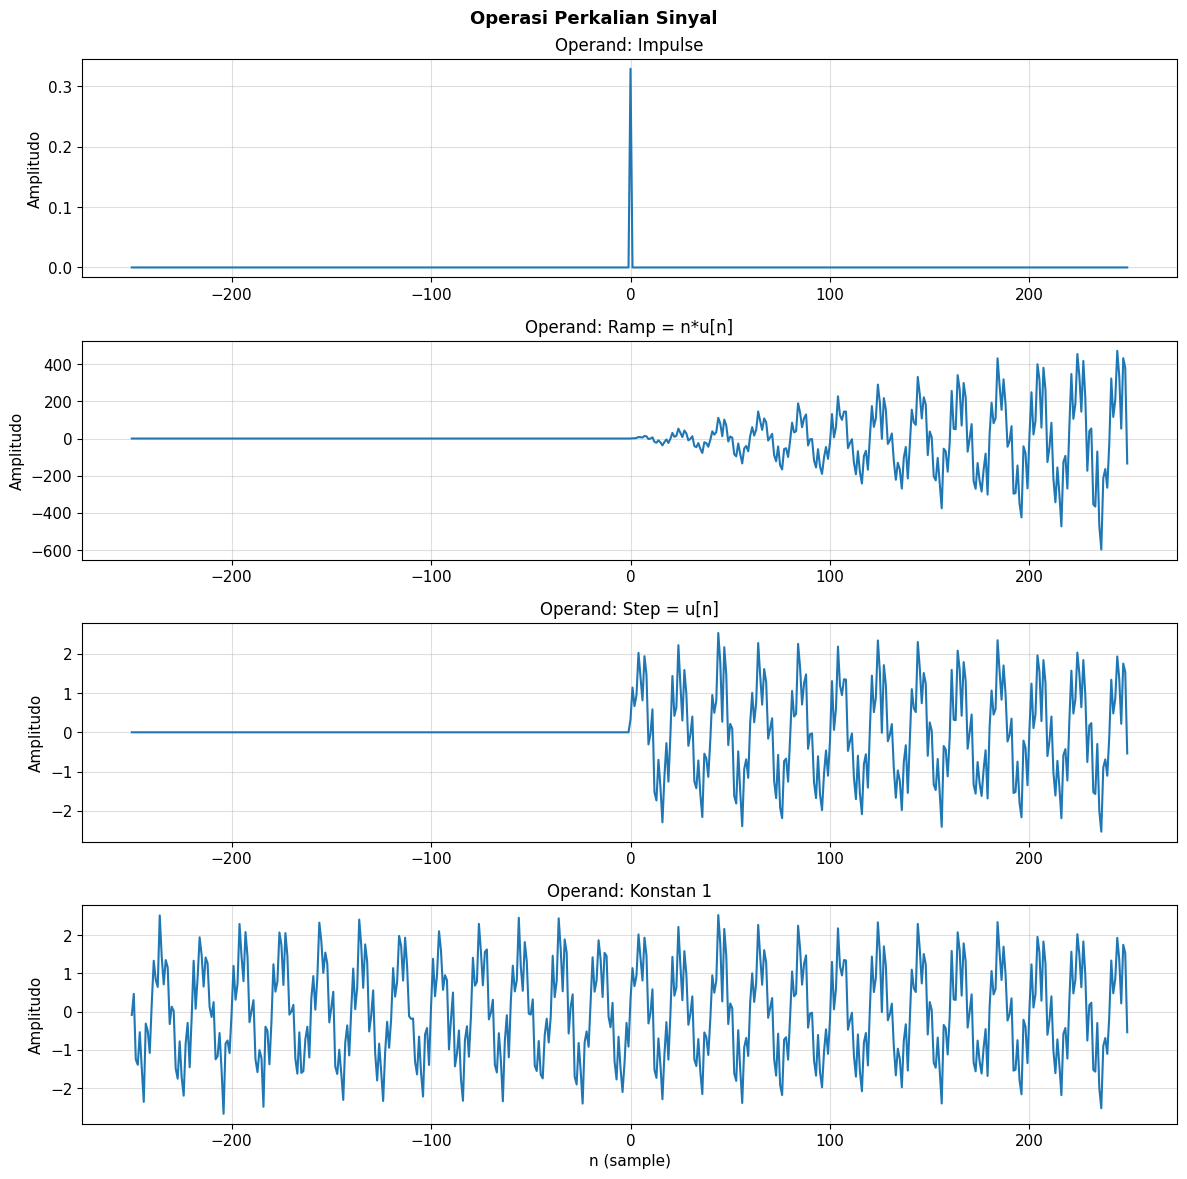

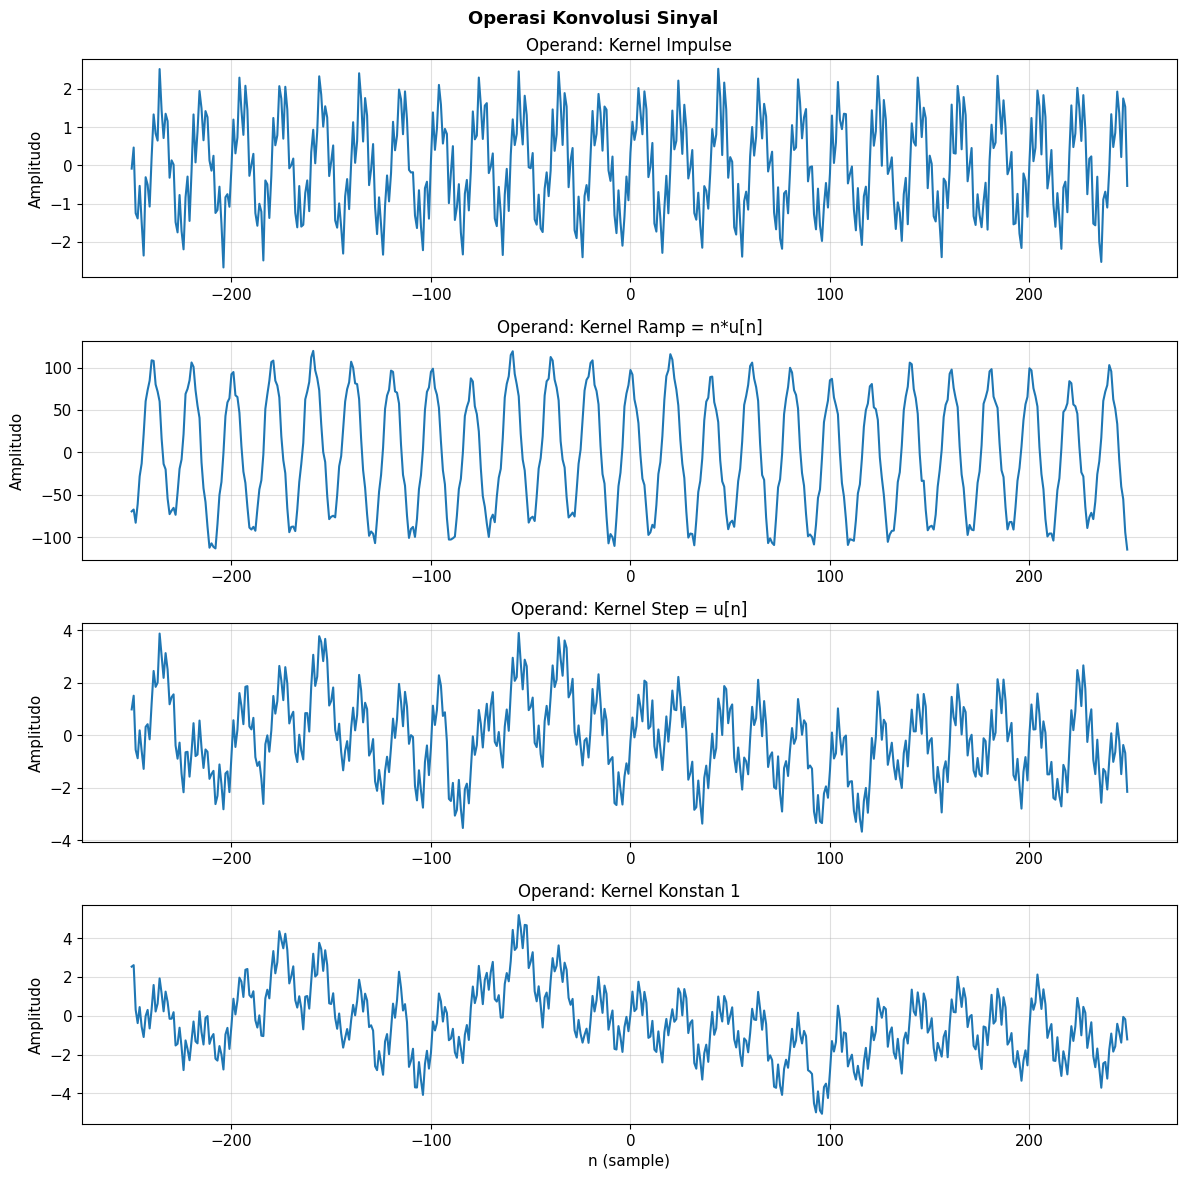

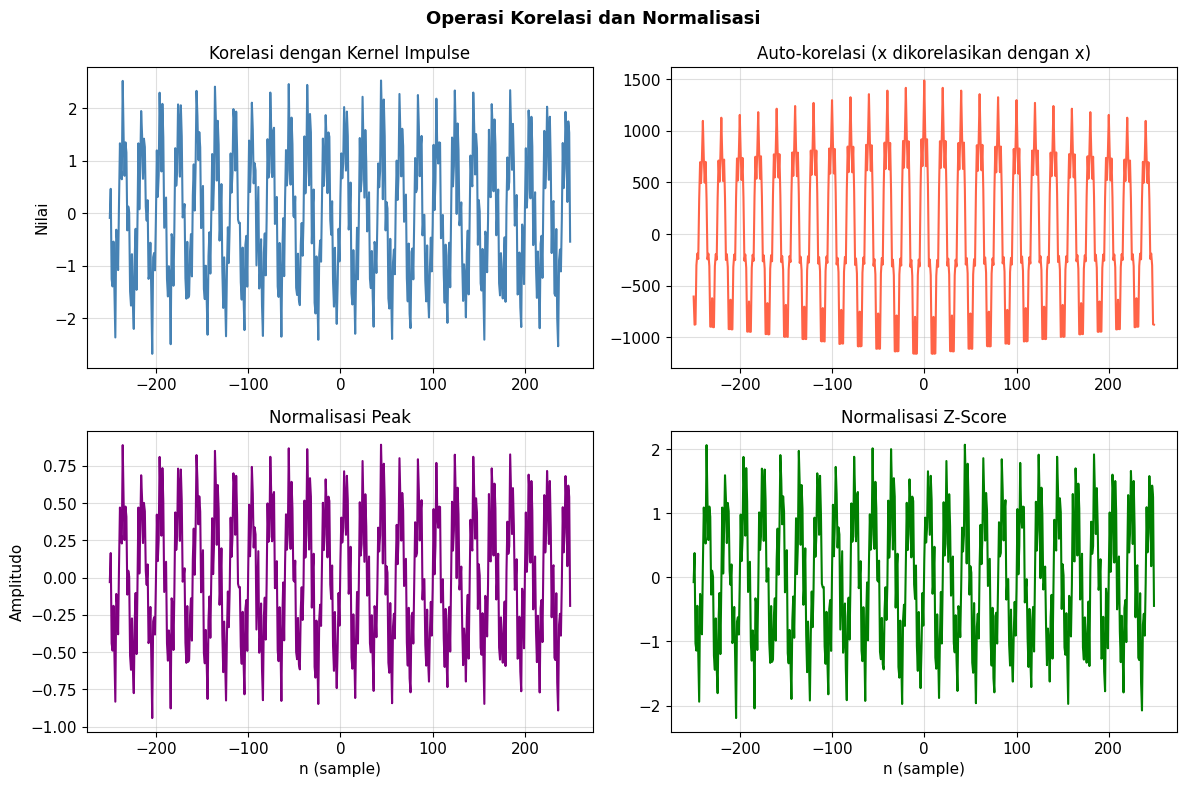


--- Operasi Dasar Sinyal Digital ---
Penjumlahan  : x + konstanta tertentu
Perkalian    : x * impulse/ramp/step/1
Konvolusi    : x dikonvolusi kernel impulse/ramp/step/1
Korelasi     : x dikorelasikan kernel impulse/ramp/step/1
Normalisasi  : peak dan z-score
Cek identitas x + 0: max error = 0.00e+00
Cek identitas x * 1: max error = 0.00e+00


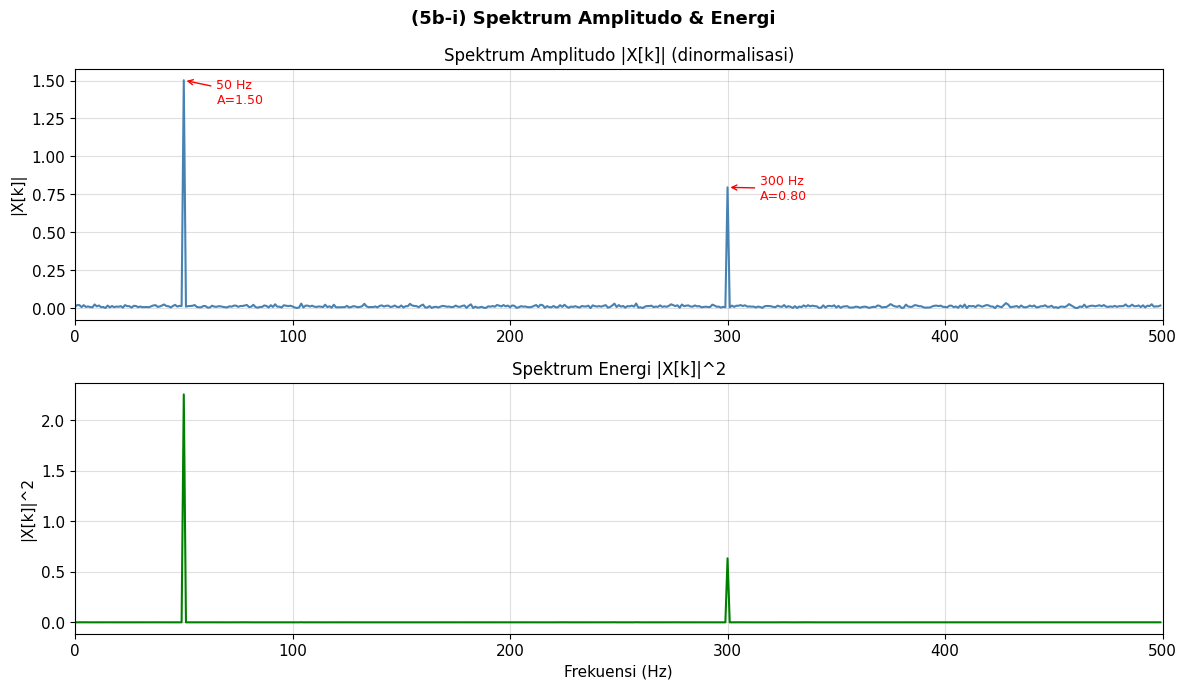

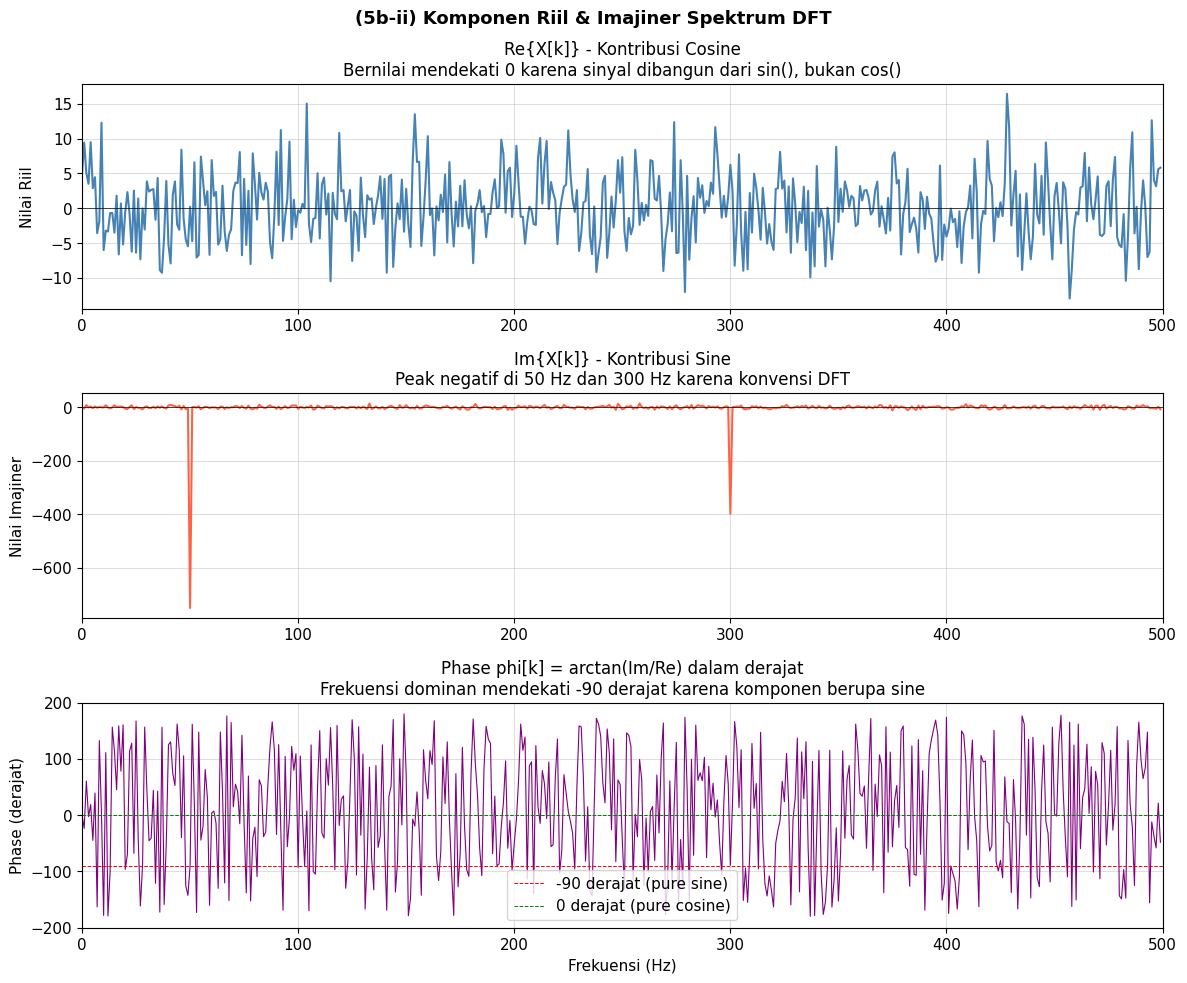


--- Nilai Re, Im, Magnitude, Phase di frekuensi dominan ---
f = 50 Hz | Re =     0.22 | Im =  -751.05 | |X| = 1.5021 | phi = -90.0 derajat
f = 300 Hz | Re =     6.24 | Im =  -398.05 | |X| = 0.7962 | phi = -89.1 derajat


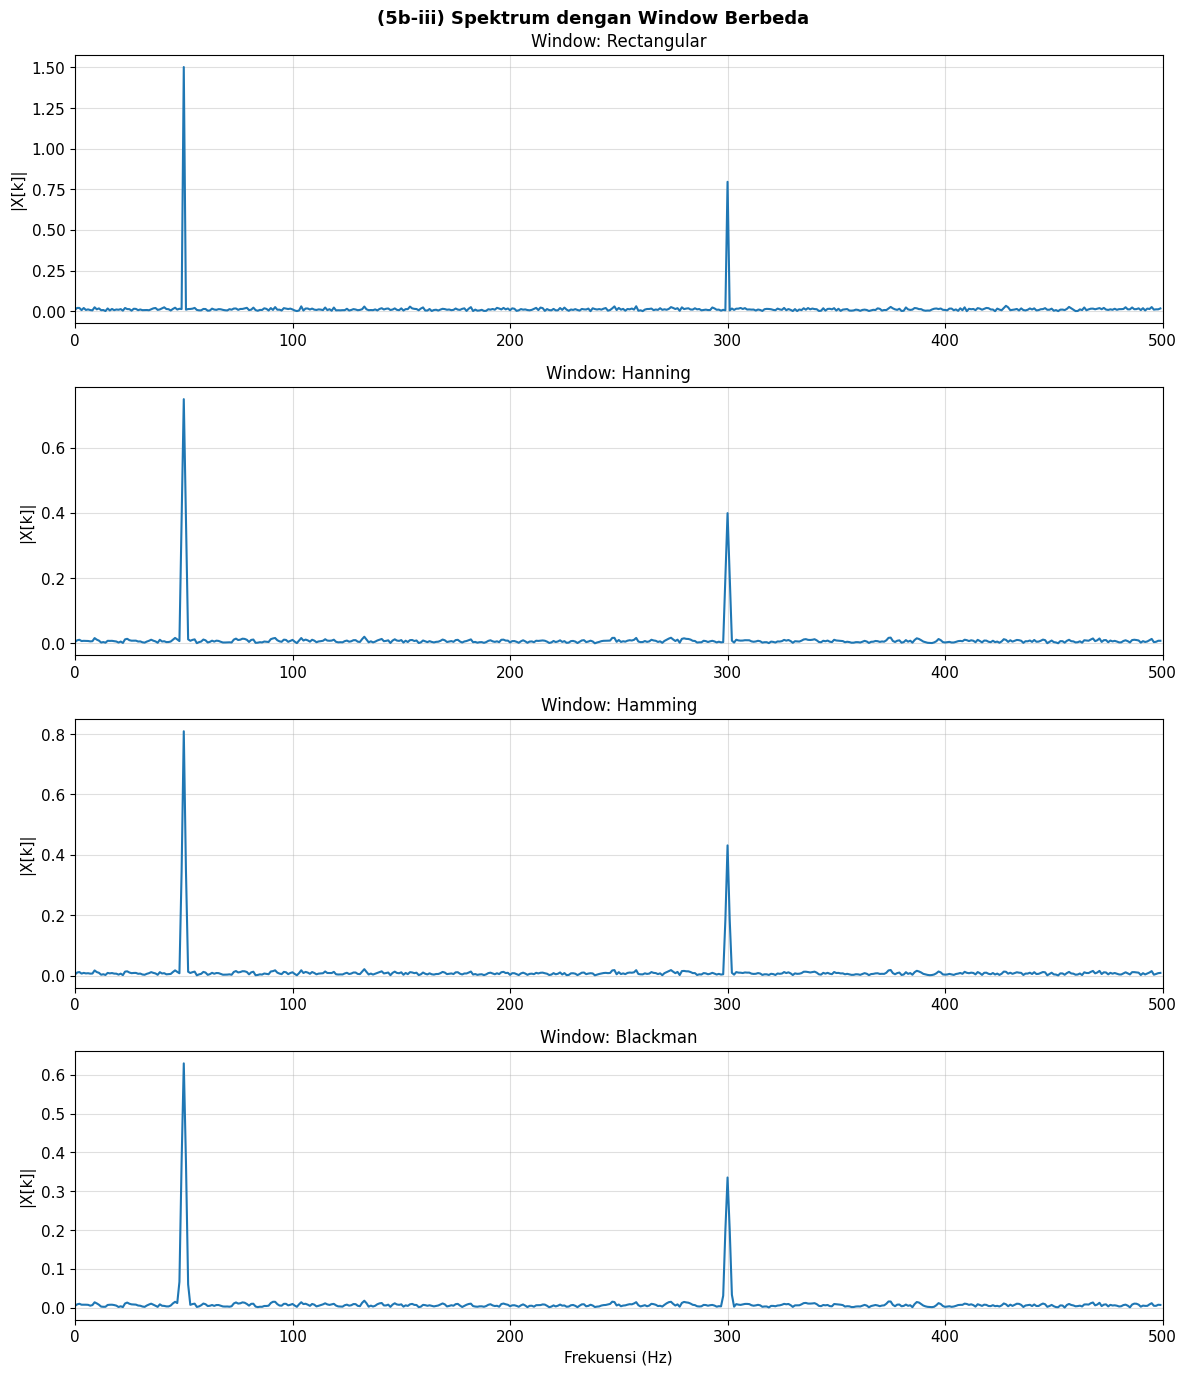


--- (5b-iv) Identifikasi Komponen Frekuensi ---
  f =   50.0 Hz | Amp = 1.5021 | BASS (< 200 Hz)
  f =  300.0 Hz | Amp = 0.7962 | TREBLE (>= 200 Hz)


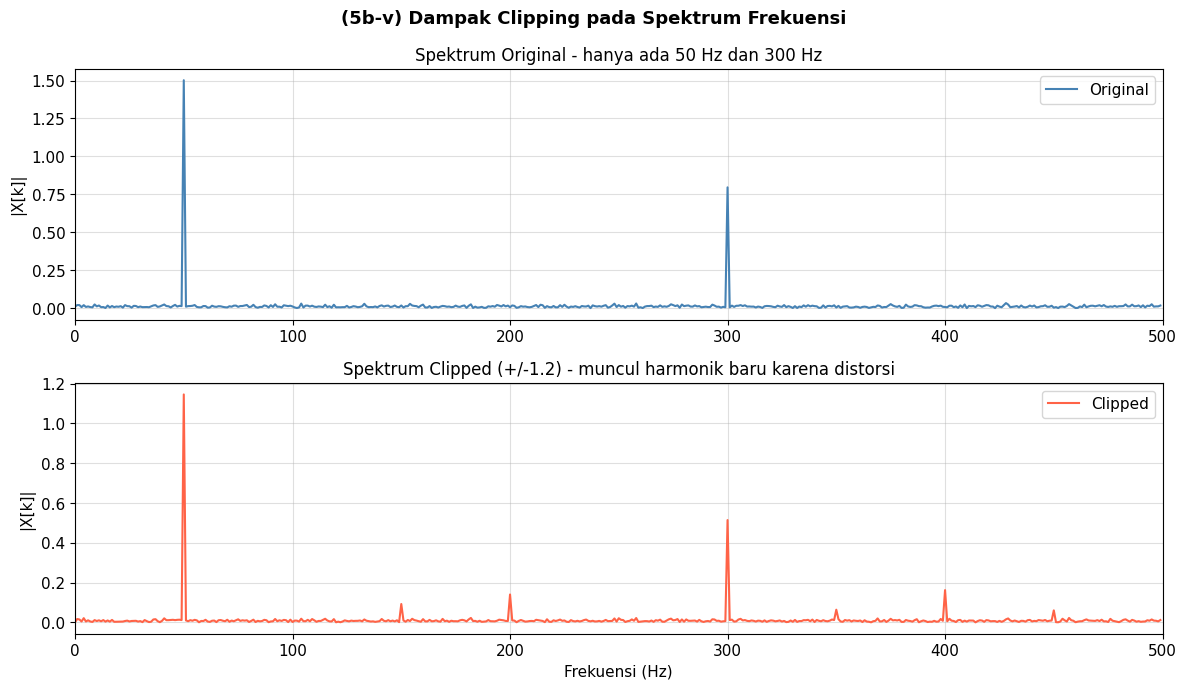


--- (5b-vi) Kemiripan Spektrum ---
Cosine similarity: 0.9839  (1.0 = identik)


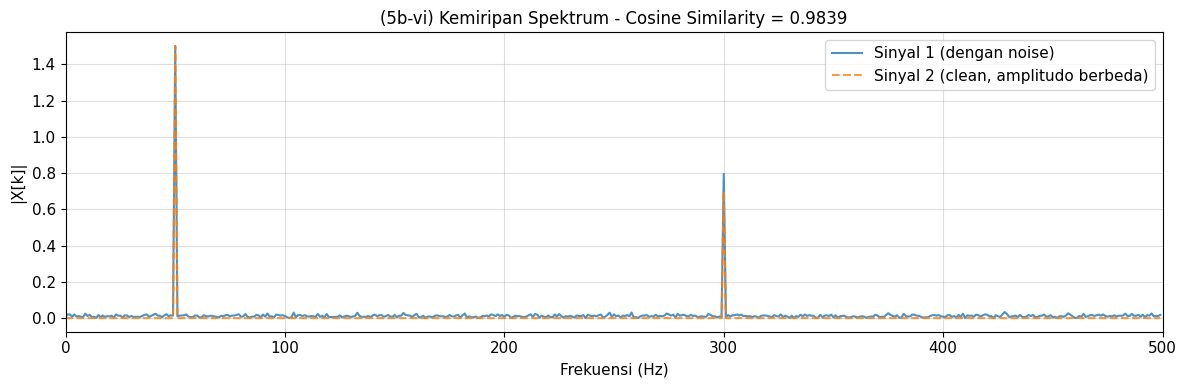

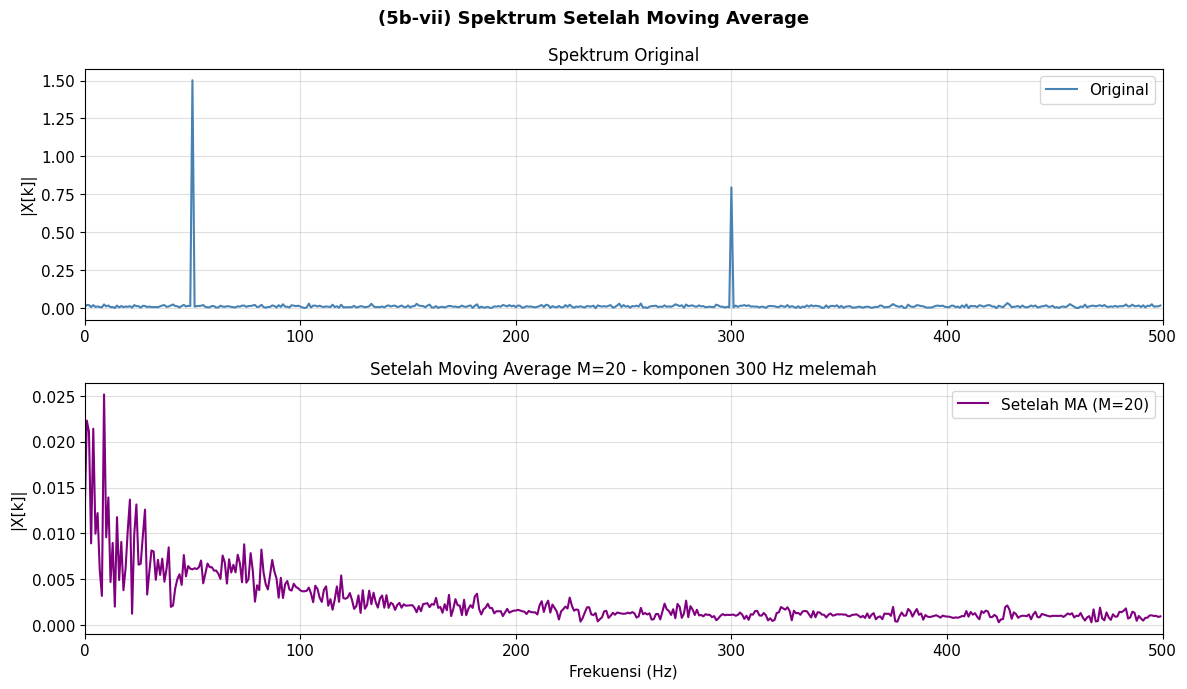


RINGKASAN OUTPUT FILE:
  5a_time_domain.png      - Plot kawasan waktu (5a-i s/d v)
  5a_ops_addition.png     - Operasi penjumlahan (4 subplot)
  5a_ops_multiplication.png - Operasi perkalian (4 subplot)
  5a_ops_convolution.png  - Operasi konvolusi (4 subplot)
  5a_ops_corr_norm.png    - Korelasi & normalisasi
  5b_i_amp_energy.png     - Spektrum amplitudo & energi
  5b_ii_real_imag.png     - Komponen Re, Im, Phase
  5b_iii_windowing.png    - Perbandingan 4 window
  5b_v_clipping_freq.png  - Dampak clipping di frekuensi
  5b_vi_similarity.png    - Kemiripan spektrum
  5b_vii_ma_spectrum.png  - Efek moving average di frekuensi
Sampling rate yang dipakai: 1000 Hz

Selesai. main.py hanya sebagai input/config router.


In [17]:
# Jalankan dari main router
result = main.main(
    input_source="synthetic",   # atau "audio"
    audio_path=None,            # isi path kalau input_source="audio"
    show_plots=True,
    save_plots=False,
    verbose=True
)